In [1]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.7.1+cu118
0.22.1+cu118


In [2]:
from going_modular import data_setup,engine,model_builder,train,utils

device="cuda" if torch.cuda.is_available() else "cpu"
device

C:\Users\Priyanshu\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cuda'

In [3]:
!nvidia-smi

Thu Jun 26 19:35:54 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.83                 Driver Version: 572.83         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   47C    P8              7W /   50W |     377MiB /   6144MiB |     36%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import os
import zipfile

from pathlib import Path

import requests

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists,skipping redownloading....")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)
    
    # Remove zip file
    os.remove(data_path / "pizza_steak_sushi.zip")

data\pizza_steak_sushi directory exists,skipping redownloading....


In [5]:
train_dir=image_path/"train"
test_dir=image_path/"test"
train_dir,test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

In [ ]:
#manual transforms
from torchvision import transforms
normalize=transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
manual_transforms=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize])

In [7]:
from going_modular import data_setup
train_dataloader,test_dataloader,class_names=data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms,
    batch_size=32,
    num_workers=0
)
train_dataloader,test_dataloader,class_names

(<torch.utils.data.dataloader.DataLoader at 0x22e4e2c0d40>,
 ['pizza', 'steak', 'sushi'])

In [9]:
#auto transforms
weights=torchvision.models.EfficientNet_B0_Weights.DEFAULT
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [10]:
auto_transforms=weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [11]:
#create dataloaders with auto transforms
train_dataloader,test_dataloader,class_names=data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=auto_transforms,
    batch_size=32
)
train_dataloader,test_dataloader,class_names

(<torch.utils.data.dataloader.DataLoader at 0x22e4e400410>,
 ['pizza', 'steak', 'sushi'])

In [41]:
#old method of  creating a pretrained model 
# model=torchvision.models.efficientnet_b0(pretrained=True)

#new method of creating a pretrained model
weights=torchvision.models.EfficientNet_B0_Weights.DEFAULT
model=torchvision.models.efficientnet_b0(weights=weights).to(device)
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [42]:
model.avgpool

AdaptiveAvgPool2d(output_size=1)

In [43]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [44]:
from torchinfo import summary
summary(model=model,
        input_size=(1,3,224,224),
        col_names=["input_size","output_size","num_params","trainable"],
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape               Output Shape              Param #                   Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]          [1, 1000]                 --                        True
├─Sequential (features)                                      [1, 3, 224, 224]          [1, 1280, 7, 7]           --                        True
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]          [1, 32, 112, 112]         --                        True
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]          [1, 32, 112, 112]         864                       True
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]         [1, 32, 112, 112]         64                        True
│    │    └─SiLU (2)                                         [1, 32, 112, 112]         [1, 32, 112, 112]         --                

In [45]:
#freezing the base layers
for param in model.features.parameters():
    param.requires_grad=False
    

In [46]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [47]:
from torch import nn
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model.classifier=nn.Sequential(
    nn.Dropout(p=0.2,inplace=True),
    nn.Linear(in_features=1280,
              out_features=len(class_names))#3
).to(device)




model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)

In [48]:
from torchinfo import summary
summary(model=model,
        input_size=(1,3,224,224),
        col_names=["input_size","output_size","num_params","trainable"],
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape               Output Shape              Param #                   Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]          [1, 3]                    --                        Partial
├─Sequential (features)                                      [1, 3, 224, 224]          [1, 1280, 7, 7]           --                        False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]          [1, 32, 112, 112]         --                        False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]          [1, 32, 112, 112]         (864)                     False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]         [1, 32, 112, 112]         (64)                      False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]         [1, 32, 112, 112]         --         

In [49]:
#train the model
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

In [50]:
from going_modular import engine

torch.manual_seed(42)
torch.cuda.manual_seed(42)

from timeit import default_timer as timer
start_time=timer()

results=engine.train(model=model,
                     train_dataloader=train_dataloader,
                     test_dataloader=test_dataloader,
                     optimizer=optimizer,
                     loss_fn=loss_fn,
                     epochs=10,
                     device=device)

end_time=timer()
print(f"[INFO] total training time: {end_time-start_time:.3f}")

 10%|█         | 1/10 [00:09<01:22,  9.13s/it]

Epoch: 1 | train_loss: 1.0947 | train_acc: 0.4023 | test_loss: 0.9138 | test_acc: 0.5502


 20%|██        | 2/10 [00:18<01:15,  9.44s/it]

Epoch: 2 | train_loss: 0.8706 | train_acc: 0.7891 | test_loss: 0.7913 | test_acc: 0.8456


 30%|███       | 3/10 [00:27<01:04,  9.23s/it]

...

Epoch: 8 | train_loss: 0.5238 | train_acc: 0.8125 | test_loss: 0.5257 | test_acc: 0.8665


 90%|█████████ | 9/10 [01:23<00:09,  9.26s/it]

Epoch: 9 | train_loss: 0.5688 | train_acc: 0.8047 | test_loss: 0.5053 | test_acc: 0.8456


100%|██████████| 10/10 [01:32<00:00,  9.26s/it]

Epoch: 10 | train_loss: 0.4878 | train_acc: 0.8203 | test_loss: 0.4394 | test_acc: 0.9062
[INFO] total training time: 92.584


In [51]:
results

{'train_loss': [1.0946868434548378,
  0.8706177473068237,
  0.7712236270308495,
  0.7126753777265549,
  0.6221082732081413,
  0.5767889060080051,
  0.5264730975031853,
  0.5238243937492371,
  0.5688373148441315,
  0.4878169074654579],
 'train_acc': [0.40234375,
  0.7890625,
  0.78515625,
  0.76171875,
  0.7890625,
  0.78125,
  0.91015625,
  0.8125,
  0.8046875,
  0.8203125],
 'test_loss': [0.9138030012448629,
  0.7913258075714111,
  0.74473504225413,
  0.6391470034917196,
  0.6277978618939718,
  0.5754715204238892,
  0.5465562542279562,
  0.525683581829071,
  0.5053325196107229,
  0.4394063353538513],
 'test_acc': [0.5501893939393939,
  0.8456439393939394,
  0.8456439393939394,
  0.8655303030303031,
  0.8560606060606061,
  0.8759469696969697,
  0.8759469696969697,
  0.8664772727272728,
  0.8456439393939394,
  0.90625]}

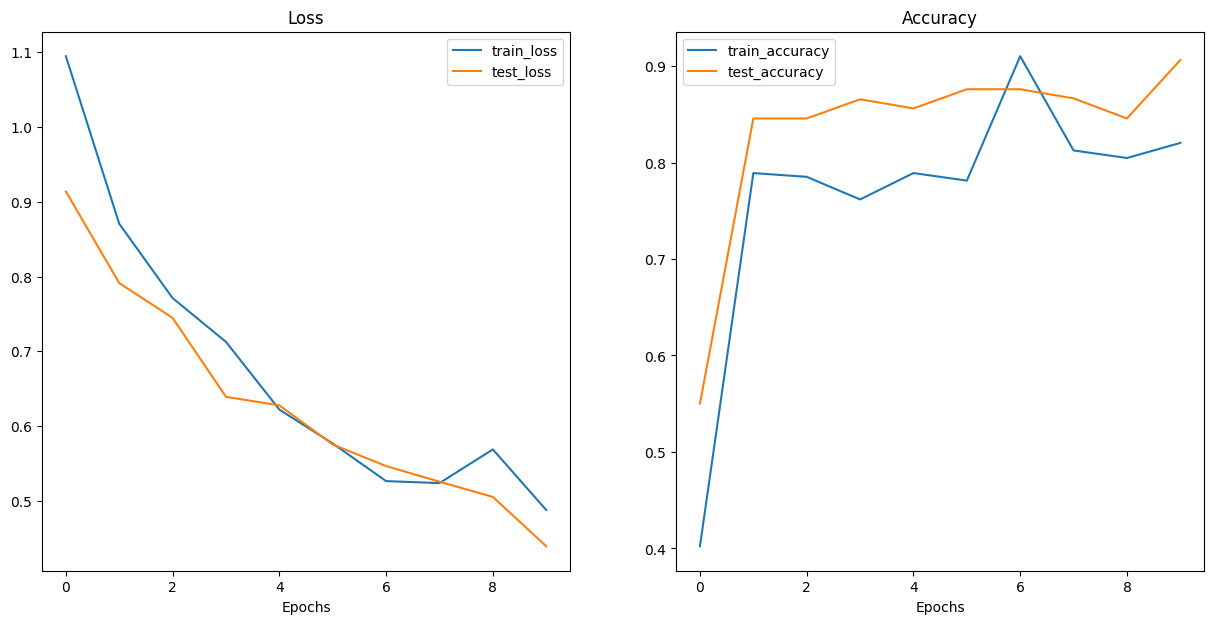

In [52]:
from helper_functions import plot_loss_curves

plot_loss_curves(results)

In [61]:
from typing import List,Tuple

from PIL import Image

from torchvision import transforms

import matplotlib.pyplot as plt

def pred_and_plot_image(model:torch.nn.Module,
                        image_path:str,
                        class_names:List[str],
                        image_size:Tuple[int,int]=(224,224),
                        transform :torchvision.transforms=None,
                        device:torch.device=device):
    img=Image.open(image_path)

    if transform is not None:
        image_transform=transform
    else:
        image_transform=transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                std=[0.229, 0.224, 0.225])
        ])

    model.to(device)

    model.eval()
    with torch.inference_mode():
        transformed_image=image_transform(img).unsqueeze(dim=0)
        target_image_pred=model(transformed_image.to(device))

    target_image_pred_probs=torch.softmax(target_image_pred,dim=1)

    target_image_pred_label=torch.argmax(target_image_pred,dim=1)
    
    plt.figure()
    plt.imshow(img)
    plt.title(f"pred:{class_names[target_image_pred_label]} |prob:{target_image_pred_probs.max():.3f}")
    plt.axis(False)

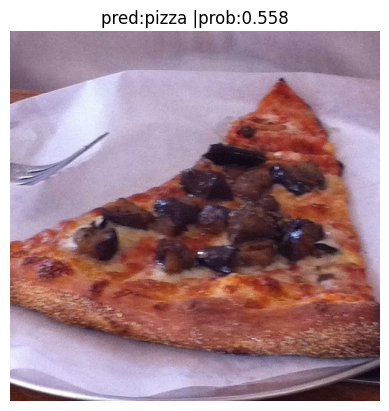

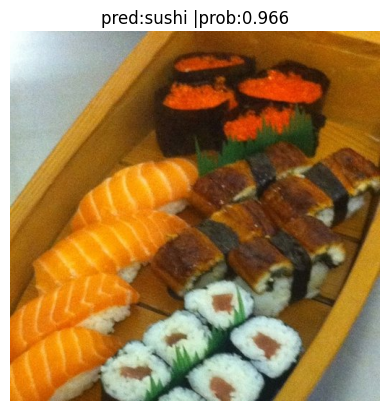

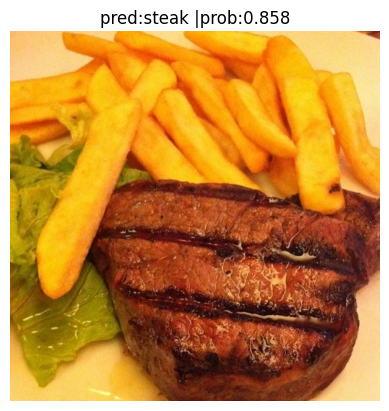

In [65]:
import random
from pathlib import Path
num_imiage_to_plot=3
test_image_path_list=list(Path(test_dir).glob("*/*.jpg"))
test_image_path_sample=random.sample(population=test_image_path_list,
                                     k=num_imiage_to_plot)

#making prediction
for image_path in test_image_path_sample:
    pred_and_plot_image(model=model,
                        image_path=image_path,
                        class_names=class_names,
                        image_size=(224,224))